In [3]:
from functions.Sliding_Functions import local_rmsd_plotter, get_significance
from functions.CIF_Functions import make_df_atomlist
from numpy import array
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [4]:
atomlist = ["CA","N","C"]
#atomlist = ["CA"]
df_ptm = make_df_atomlist("cif_files/Predictions/SEEDMATCHED/fold_adnan_seed42_ptms/fold_adnan_seed42_ptms_model_3.cif",atomlist)
df_noptm = make_df_atomlist("cif_files/Predictions/SEEDMATCHED/fold_adnan_seed1_noptms/fold_adnan_seed1_noptms_model_1.cif",atomlist)
df_ptm126 = make_df_atomlist("cif_files/Predictions/REM_MANNOSE/fold_seed42_ptms_minus126/fold_seed42_ptms_minus126_model_4.cif",atomlist)
df_ptm20x = make_df_atomlist("cif_files/Predictions/REM_MANNOSE/fold_seed42_ptms_minus20x/fold_seed42_ptms_minus20x_model_3.cif",atomlist)
df_crystal_ptm = make_df_atomlist("cif_files/Crystals/7stz (1).cif",atomlist)  # this should be aligned to noptm differently
df_crystal_noptm = make_df_atomlist("cif_files/Crystals/2o72.cif",atomlist)      # idem
# noca
df_ptm_noca = make_df_atomlist("cif_files/Predictions/CALCIUMLESS/with_ptm/fold_adnan_seed42_ptms_noca/fold_adnan_seed42_ptms_noca_model_1.cif",atomlist)
df_noptm_noca = make_df_atomlist("cif_files/Predictions/CALCIUMLESS/fold_seed51_noca/fold_seed51_noca_model_1.cif",atomlist)

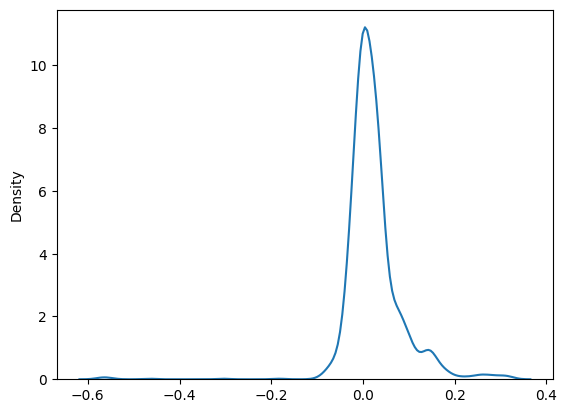

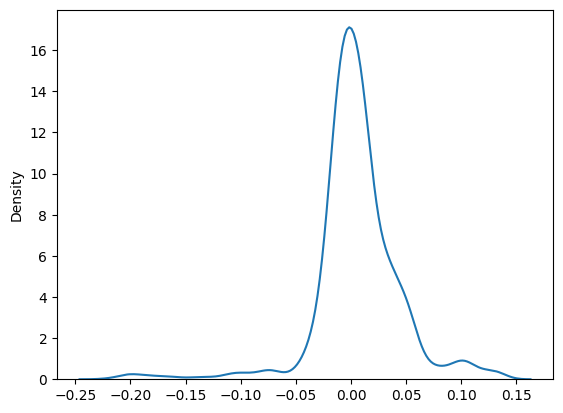

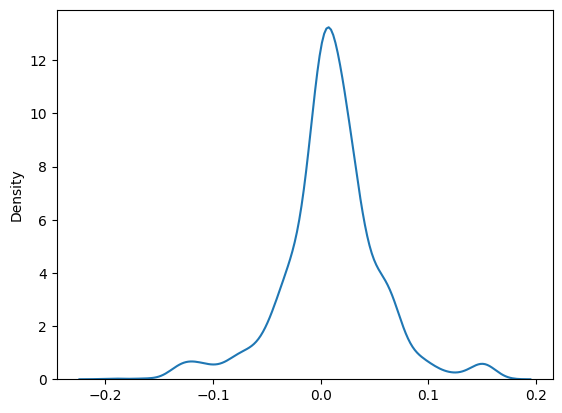

In [7]:

for a in [df_ptm,df_ptm126,df_ptm20x]:
    b = df_noptm
    c = df_crystal_ptm

    step = 1
    win = 75
    x,y1,_ = local_rmsd_plotter(a,c,stepsize=step,win_size=win)
    x,y2,_ = local_rmsd_plotter(b,c,stepsize=step,win_size=win)

    data= array(y2)-array(y1)
    sns.kdeplot(data)
    plt.show()
    get_significance(y1,y2)


In [ ]:
import numpy as np
import scipy
a= df_ptm126
b = df_noptm
c = df_crystal_ptm

step = 1
win = 75
x,y1,_ = local_rmsd_plotter(a,c,stepsize=step,win_size=win)
x,y2,_ = local_rmsd_plotter(b,c,stepsize=step,win_size=win)
data = array(y2)-array(y1)
x,y = sns.kdeplot(data).lines[0].get_data()
plt.close()

densplot = [(i[0],i[1]) for i in zip(x,y)]
sym_neg = array([i for i in densplot if i[0]<0] + [(-1*i[0],i[1]) for i in densplot[::-1] if i[0]<0])
x_vals = sym_neg[:, 0]
y_vals = sym_neg[:, 1]

# Normalize the y values to ensure the total area is 1
y_normalized = y_vals / np.trapz(y_vals, x_vals)
# Calculate the CDF
mean = 0
variance = np.sum((x_vals - mean)**2 * y_normalized) / np.sum(y_normalized)
std_dev = np.sqrt(variance)
print(std_dev)

# Calculate the CDF
mean = 0
variance = np.sum((x_vals - mean)**2 * y_vals) / np.sum(y_vals)
std_dev = np.sqrt(variance)
print(std_dev)



0.043030388703979024
0.043030388703979024


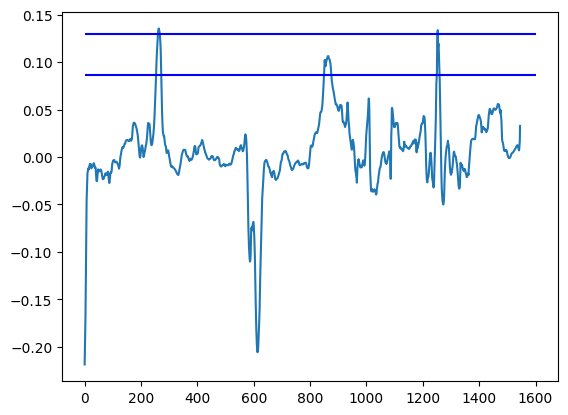

In [ ]:
plt.plot(data)
plt.hlines([2*std_dev,3*std_dev],0,1600,color="blue")


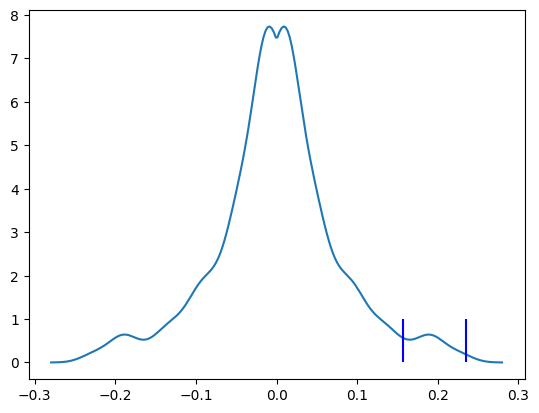

In [ ]:
for a,title in [(df_noptm_noca,"noptm_noca")]:
    b = df_noptm
    c = df_crystal_ptm
    step = 1
    win = 75
    x,y1,_ = local_rmsd_plotter(a,c,stepsize=step,win_size=win)
    x,y2,_ = local_rmsd_plotter(b,c,stepsize=step,win_size=win)
    plt.title(f"noptm vs {title}")
    get_significance(y1,y2,plots=True)
    



TypeError: get_significance() got multiple values for argument 'plots'

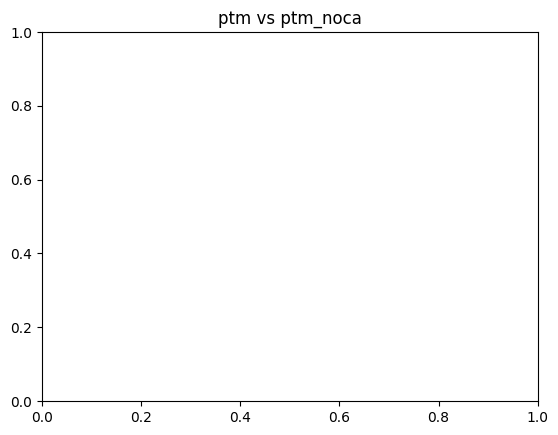

In [ ]:
for a,title in [(df_ptm_noca,"ptm_noca")]:
    b = df_ptm
    c = df_crystal_ptm
    step = 1
    win = 75
    x,y1,_ = local_rmsd_plotter(a,c,stepsize=step,win_size=win)
    x,y2,_ = local_rmsd_plotter(b,c,stepsize=step,win_size=win)
    plt.title(f"ptm vs {title}")
    get_significance(x,y1,y2,plots=True)